<a href="https://colab.research.google.com/github/Dayfeed22/DEVELOPMENT-OF-CONCRETE-WATER-CEMENT-RATIO-PREDICTION-SYSTEM/blob/main/DAVE_UML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
file_path = 'DAVE UML.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows of the dataset
data.head()


,Cement (kg/m3),Sand (kg/m3),Granite (kg/m3),Age (days),Water (kg/m3),w/c,Slump (mm),Density (kg/m3),Compressive strength (N/mm2)
0,263,788.3,1576.7,7,170.95,0.65,6,2014,4.89
1,263,788.3,1576.7,7,170.95,0.65,6,2122,7.56
2,263,788.3,1576.7,7,170.95,0.65,6,2044,6.89
3,263,788.3,1576.7,7,170.95,0.65,6,2252,7.11
4,263,788.3,1576.7,7,170.95,0.65,6,2074,5.56


In [ ]:
# Check for missing values
missing_values = data.isnull().sum()

# Get basic statistics of the dataset
data_statistics = data.describe()

missing_values, data_statistics


(Cement (kg/m3)                  0
 Sand (kg/m3)                    0
 Granite (kg/m3)                 0
 Age (days)                      0
 Water (kg/m3)                   0
 w/c                             0
 Slump (mm)                      0
 Density (kg/m3)                 0
 Compressive strength (N/mm2)    0
 dtype: int64,
        Cement (kg/m3)  Sand (kg/m3)  Granite (kg/m3)  Age (days)  \
 count       72.000000     72.000000        72.000000    72.00000   
 mean       355.666667    721.066667      1442.133333    17.50000   
 std         84.398785     48.807596        97.693040     7.88116   
 min        263.000000    675.900000      1351.700000     7.00000   
 25%        263.000000    675.900000      1351.700000    12.25000   
 50%        338.000000    699.000000      1398.000000    17.50000   
 75%        466.000000    788.300000      1576.700000    22.75000   
 max        466.000000    788.300000      1576.700000    28.00000   
 
        Water (kg/m3)    w/c  Slump (mm)  Densi

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target variable
features = data[['Cement (kg/m3)', 'Sand (kg/m3)', 'Granite (kg/m3)', 'Age (days)', 'Water (kg/m3)', 'Slump (mm)', 'Density (kg/m3)', 'Compressive strength (N/mm2)']]
target = data['w/c']

# Normalize the features
scaler = StandardScaler()
normalized_features = scaler.fit_transform(features)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(normalized_features, target, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


((57, 8), (15, 8), (57,), (15,))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network architecture
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(64, input_dim=8, activation='relu'))

# Second hidden layer
model.add(Dense(32, activation='relu'))

# Third hidden layer
model.add(Dense(16, activation='relu'))

# Output layer
model.add(Dense(1, activation='linear'))

# Display the summary of the model
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3201 (12.50 KB)
Trainable params: 3201 (12.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Compile the model
model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_absolute_error']
)

# Display the model summary again to confirm the compilation
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3201 (12.50 KB)
Trainable params: 3201 (12.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=10,
    validation_split=0.2
)


Epoch 1/100
5/5 [==============================] - 2s 179ms/step - loss: 0.2769 - mean_absolute_error: 0.5126 - val_loss: 0.0871 - val_mean_absolute_error: 0.2721
Epoch 2/100
5/5 [==============================] - 0s 44ms/step - loss: 0.0927 - mean_absolute_error: 0.2556 - val_loss: 0.0229 - val_mean_absolute_error: 0.1337
Epoch 3/100
5/5 [==============================] - 0s 34ms/step - loss: 0.0376 - mean_absolute_error: 0.1564 - val_loss: 0.0444 - val_mean_absolute_error: 0.1641
Epoch 4/100
5/5 [==============================] - 0s 38ms/step - loss: 0.0376 - mean_absolute_error: 0.1713 - val_loss: 0.0455 - val_mean_absolute_error: 0.1713
Epoch 5/100
5/5 [==============================] - 0s 57ms/step - loss: 0.0228 - mean_absolute_error: 0.1266 - val_loss: 0.0157 - val_mean_absolute_error: 0.0928
Epoch 6/100
5/5 [==============================] - 0s 64ms/step - loss: 0.0076 - mean_absolute_error: 0.0638 - val_loss: 0.0050 - val_mean_absolute_error: 0.0530
Epoch 7/100
5/5 [==========

In [ ]:
# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test MAE: {test_mae}')


1/1 [==============================] - 0s 50ms/step - loss: 0.0019 - mean_absolute_error: 0.0277
Test Loss: 0.001866153790615499
Test MAE: 0.027721205726265907


In [ ]:
# Save the model in the recommended Keras format
model.save('water_cement_ratio_predictor.keras')

# Load the model
loaded_model = tf.keras.models.load_model('water_cement_ratio_predictor.keras')

# Example prediction
import numpy as np

# Assuming new_data is a numpy array with shape (1, 8) representing a single new sample
new_data = np.array([[300, 700, 1400, 14, 200, 20, 2400, 18]])
new_data_normalized = scaler.transform(new_data)
prediction = loaded_model.predict(new_data_normalized)

print(f'Predicted Water-Cement Ratio: {prediction[0][0]}')


1/1 [==============================] - 0s 62ms/step
Predicted Water-Cement Ratio: 0.3241150975227356


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


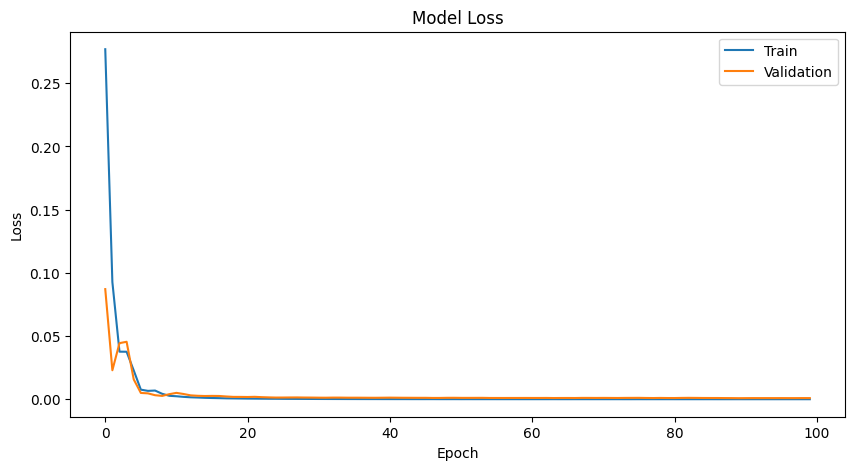

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


1/1 [==============================] - 0s 22ms/step


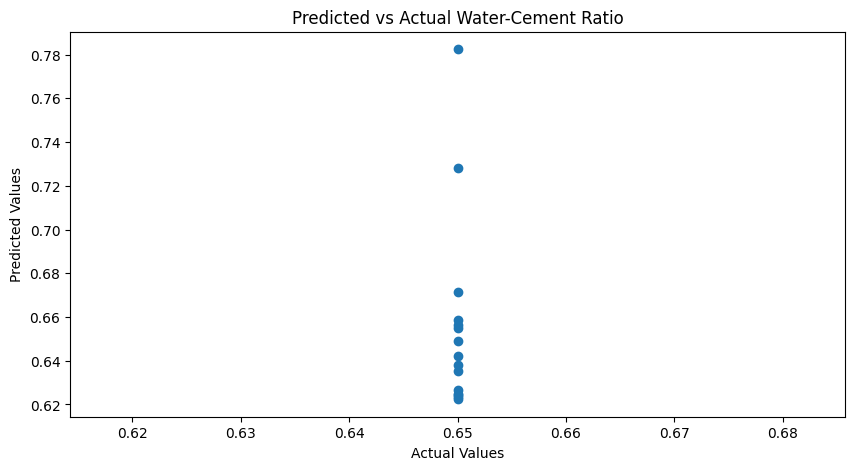

In [ ]:
# Make predictions on the test set
predictions = loaded_model.predict(X_test)

# Plot predicted vs actual values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.title('Predicted vs Actual Water-Cement Ratio')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


1/1 [==============================] - 0s 32ms/step


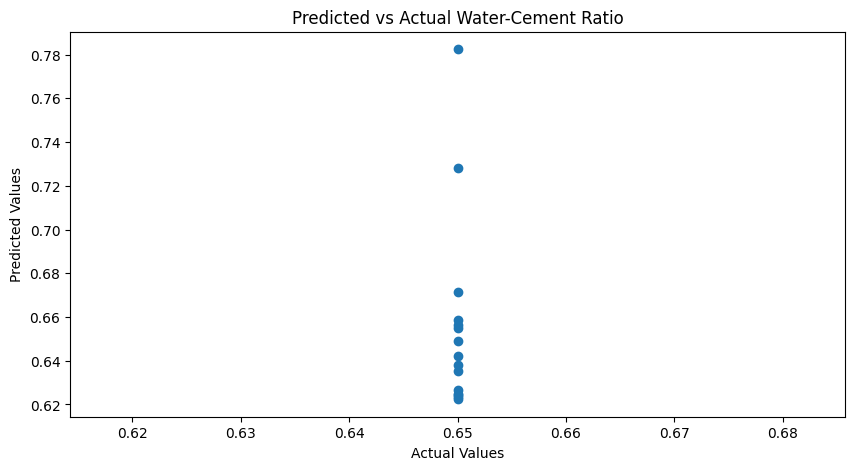

In [ ]:
import matplotlib.pyplot as plt

# Make predictions on the test set
predictions = loaded_model.predict(X_test)

# Plot predicted vs actual values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.title('Predicted vs Actual Water-Cement Ratio')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Assume 'scaler' is the StandardScaler used earlier, and the target was not scaled

# Check the original scale of the target 'w/c'
# Normally, if the scaler was applied to the features, predictions should not need rescaling

# For demonstration, here's how to manually adjust predictions if needed
# If predictions need to be within the range [min_actual, max_actual]
min_actual = data['w/c'].min()
max_actual = data['w/c'].max()

# Scale the predictions back to the [min_actual, max_actual] range
predictions_rescaled = np.interp(predictions.flatten(), (predictions.min(), predictions.max()), (min_actual, max_actual))

# Create a DataFrame with actual and rescaled predicted values
results_rescaled = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions_rescaled
})

# Display the first few rows of the DataFrame
results_rescaled.head()


,Actual,Predicted
4,0.65,0.65
62,0.65,0.65
18,0.65,0.65
0,0.65,0.65
28,0.65,0.65


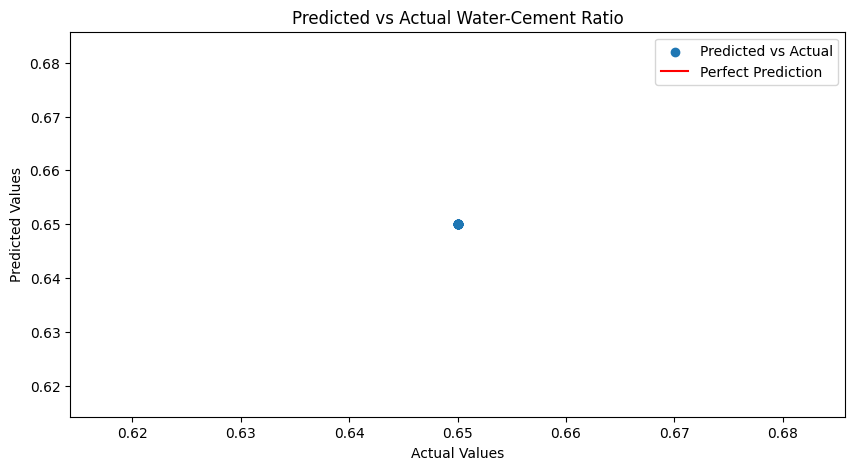

In [ ]:
# Plot predicted vs actual values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, predictions_rescaled, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r', label='Perfect Prediction')
plt.title('Predicted vs Actual Water-Cement Ratio')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()


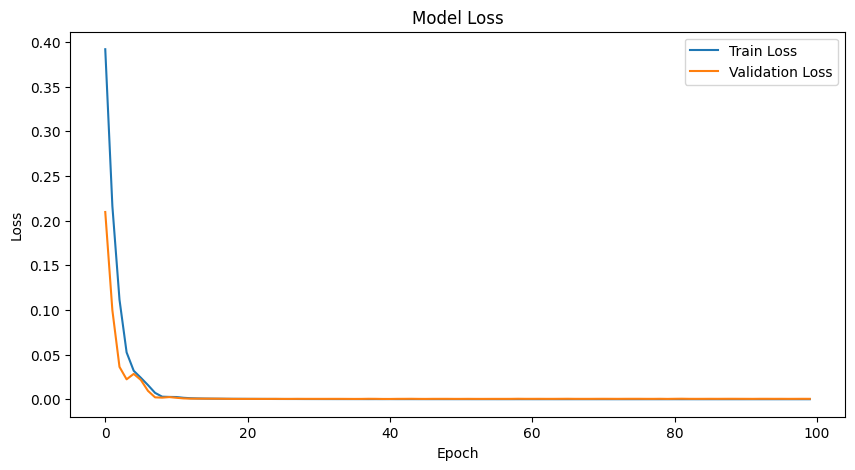

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


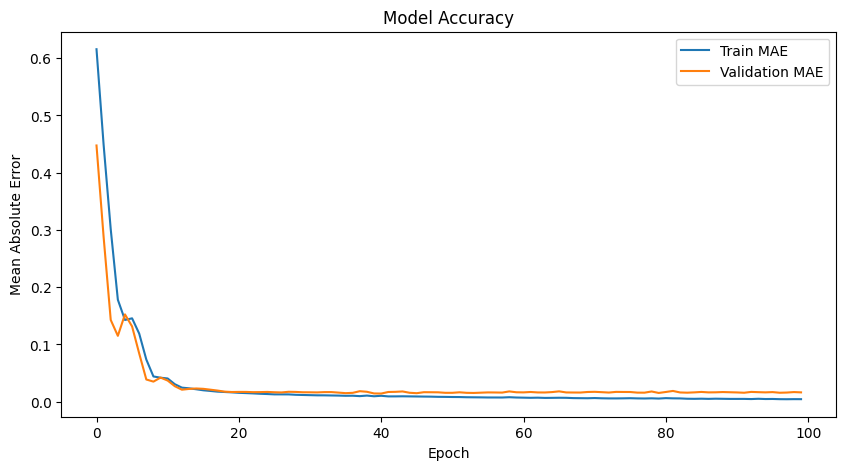

In [ ]:
# Plot training & validation MAE values
plt.figure(figsize=(10, 5))
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.show()


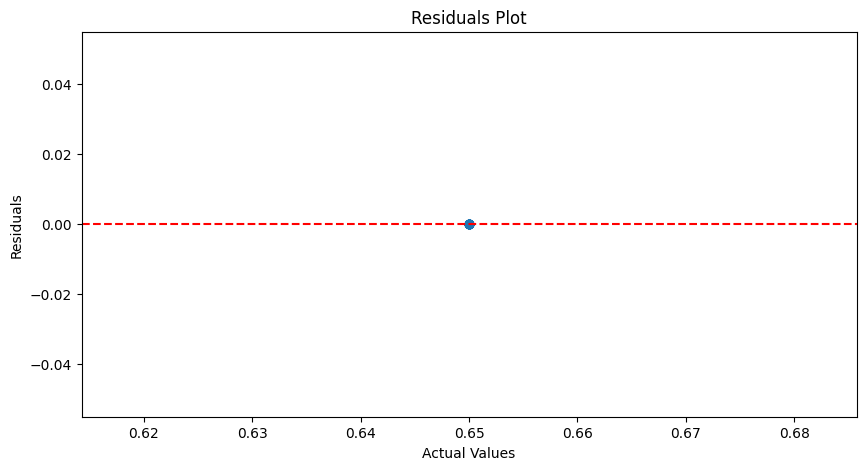

In [ ]:
# Calculate residuals
residuals = y_test - predictions_rescaled

# Plot residuals
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.show()


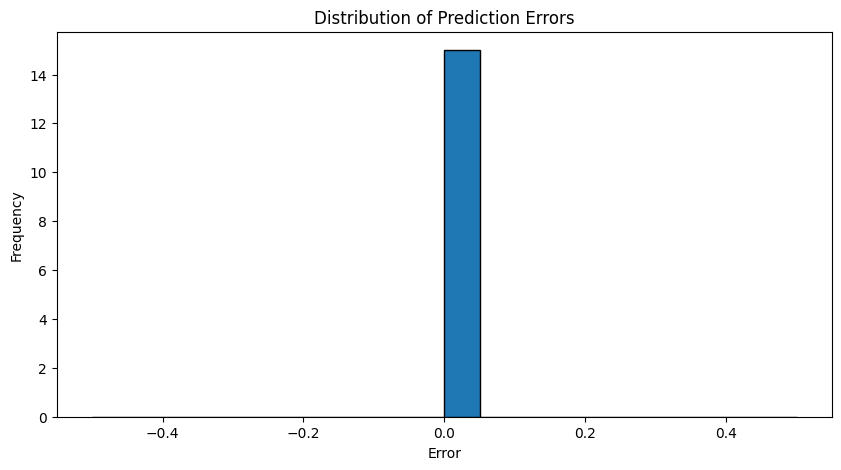

In [ ]:
# Plot distribution of errors
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=20, edgecolor='k')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()


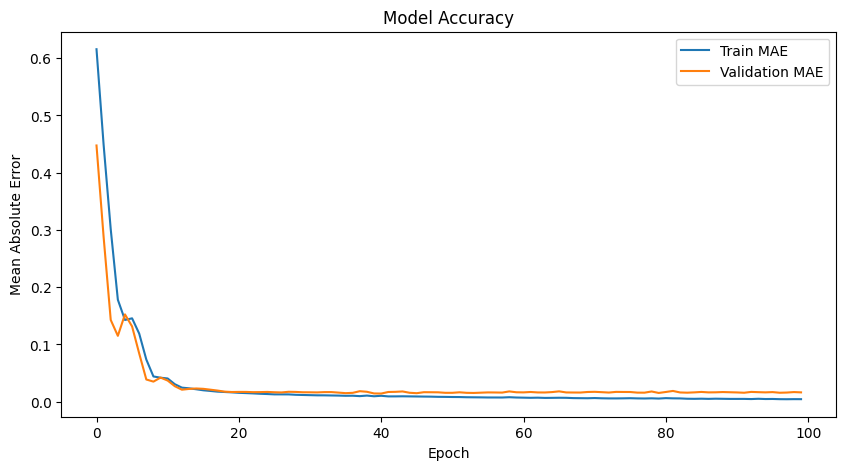

In [ ]:
# Plot training & validation MAE values
plt.figure(figsize=(10, 5))
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.show()
